# Introduction
The project uses an autoencoder to model standard LHC (Large Hadron Collider) interactions and detect deviations that may signal novel physics. By training on well-understood events, the autoencoder learns typical patterns and brings the training error rate very low. By reconstructing events which may contian new useful interactions and analysing the error values of the reconstructions, we can reveal potential anomalies that could indicate new particles or interactions.

# Data
We'll start by importing our dataset and performing some cleaning to prepare it for the model. At the same time, we'll clearly separate the data into training and testing sets.

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import urllib.request

from torch import nn
import torch.nn.functional
import torch.optim
import torch.utils.data
import pandas as pd
import torch
import itertools
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(123)
torch.cuda.manual_seed(123)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [ ]:
signalfile='events_anomalydetection_Z_XY_qqq__out.h5'
urllib.request.urlretrieve("http://mhance.scipp.ucsc.edu/152/%s" % signalfile, signalfile)

backgrfile='events_anomalydetection_v2__out.h5'
urllib.request.urlretrieve("http://mhance.scipp.ucsc.edu/152/%s" % backgrfile, backgrfile)

('events_anomalydetection_v2__out.h5',
 <http.client.HTTPMessage at 0x7f949baab790>)

In [ ]:
with h5py.File(signalfile, 'r+') as hdf5file:
    print("Here are the keys in this file")
    print(hdf5file.keys())
    print("\n")

    datagroup=hdf5file['data']
    jetinfogroup=hdf5file['jet_infos']

    datalabels = [
        'is_signal',
        'Mjj',
        'Mj1',
        'j1 sqrt(tau^2_1)/tau^1_1',
        'j1 tau21',
        'j1 tau32',
        'j1 tau43',
        'j1 ntrk',
        'Mj2',
        'j2 sqrt(tau^2_1)/tau^1_1',
        'j2 tau21',
        'j2 tau32',
        'j2 tau43',
        'j2 ntrk'
    ]

    # for this analysis we will be ignoring the jetinfolabels.
    jetinfolabels = [
        'jets[0].pt()',
        'jets[0].eta()',
        'jets[0].phi()',
        'jets[0].m()',
        'jets[1].pt()',
        'jets[1].eta()',
        'jets[1].phi()',
        'jets[1].m()',
        'jet3.pt()',
       'jet3.eta()',
        'jet3.phi()',
        'jet3.m()',
        'mjj',
        'mjjj',
        'met_pt',
        'met_phi',
        'njets'
    ]

    dataindeces=[0,1,2,3,4,5,6,7,8,9,10,11,12,13]

    datagroup.attrs['labels'] = datalabels
    jetinfogroup.attrs['labels'] = jetinfolabels

    datagroup.names = datalabels
    jetinfogroup.names = jetinfolabels

    # we'll now collect all our data into alldata with the first
    # num_signal_events being the data that contians standard explainable
    # interactions. We will use this data to train the model and the rest of the
    # data which may contian new interactions will be used for testing


    with h5py.File(signalfile, 'r') as hdf5file:
      data=hdf5file[list(hdf5file.keys())[0]]
      num_signal_events=len(data[:,0])
      alldata = []
      for i in range(num_signal_events):
        alldata.append(list(data[i]))

    with h5py.File(backgrfile,'r') as hdf5file:
      data=hdf5file[list(hdf5file.keys())[0]]
      num_backgr_events=len(data[:,0])
      for i in range(num_backgr_events):
        alldata.append(list(data[i]))

Here are the keys in this file
<KeysViewHDF5 ['data', 'jet_infos']>




Next, we'll consolidate all our data into a single dataset, alldata. The first num_signal_events consist of standard, explainable interactions that will serve as our training data, while the remaining data—potentially containing new interactions—will be used for testing.

In [ ]:
Alldata=[[float(i) for i in j] for j in alldata]

X_train = Alldata[:num_signal_events]
X_test = Alldata[num_signal_events:]

print(len(X_test))
print(len(X_train))

1100000
100000


Lets now view the training data we have:

In [ ]:
X_train_before_scaling={}
for b in dataindeces:
    X_train_before_scaling[b]=[event[dataindeces[b]] for event in X_train]

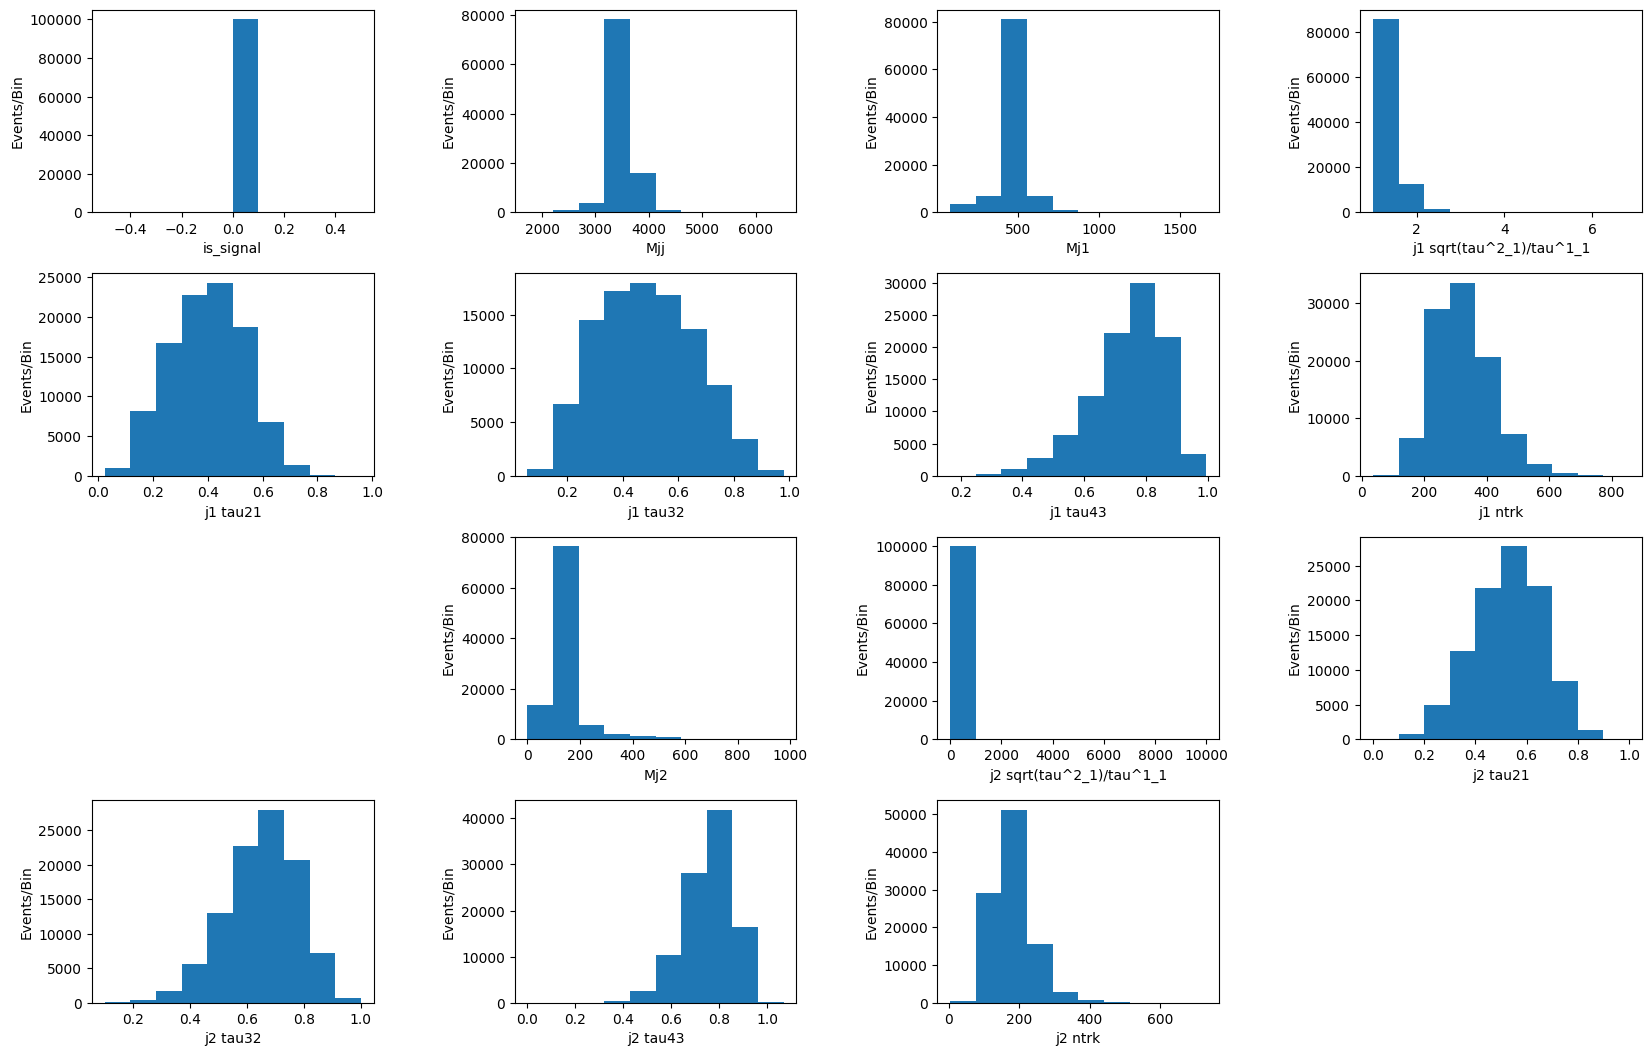

In [ ]:
fig = plt.figure(figsize=(20,30))
fig.tight_layout()
for b in range(len(dataindeces)):
    ax=fig.add_subplot(9,4,1+b if b<8 else 2+b)
    plt.subplots_adjust(hspace=0.3,wspace=0.5)
    ax.hist(X_train_before_scaling[dataindeces[b]])
    ax.set_xlabel(datalabels[dataindeces[b]])
    ax.set_ylabel("Events/Bin")

These all have very different value ranges which could confuse our model, lets now scale all our data so that it has values between [0,1].

In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()

X_train = sc.fit_transform(X_train)

In [ ]:
X_train_after_scaling={}
for b in dataindeces:
    X_train_after_scaling[b]=[event[dataindeces[b]] for event in X_train]

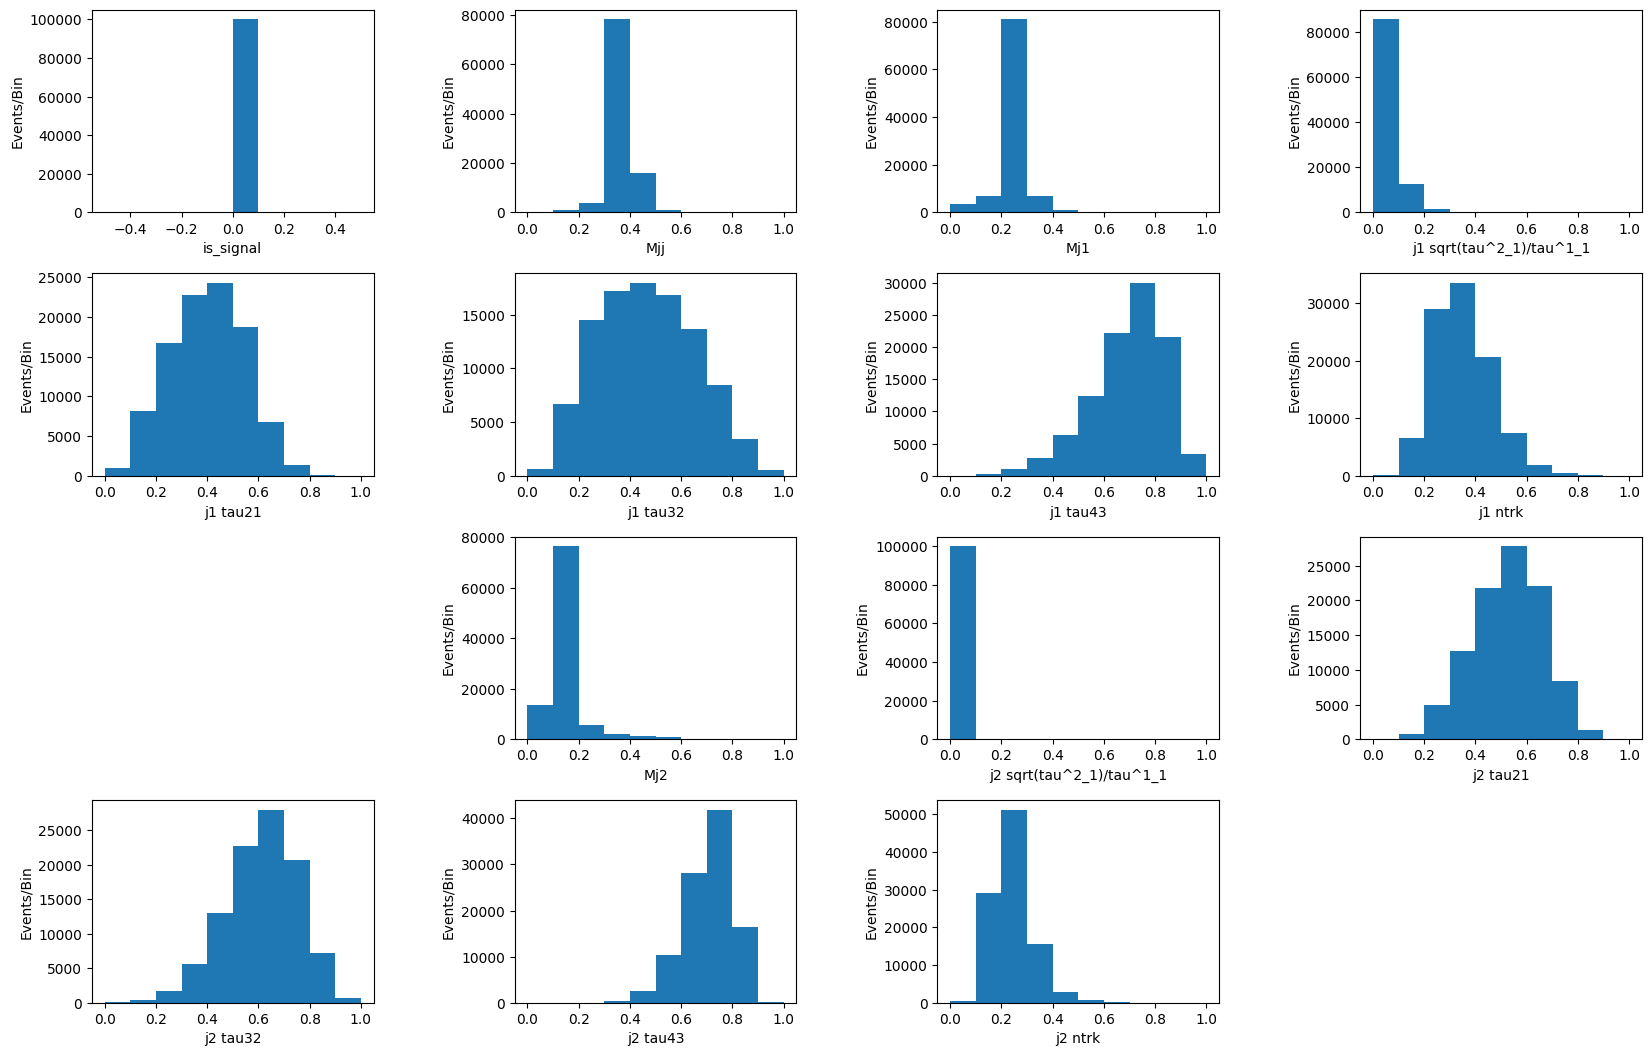

In [ ]:
fig = plt.figure(figsize=(20,30))
fig.tight_layout()
for b in range(len(dataindeces)):
    ax=fig.add_subplot(9,4,1+b if b<8 else 2+b)
    plt.subplots_adjust(hspace=0.3,wspace=0.5)
    ax.hist(X_train_after_scaling[dataindeces[b]])
    ax.set_xlabel(datalabels[dataindeces[b]])
    ax.set_ylabel("Events/Bin")

In [ ]:
X_test = sc.transform(X_test)

In [ ]:
# sanity check to insure all our data has 14 features and that the training data
# is much smaller than the testing data.

print(X_train.data.shape)
print(X_test.data.shape)

(100000, 14)
(1100000, 14)


# Parameters
Now that our data looks good, let's set everything up using some preset hyperparameters, which we can optimize later.

In [ ]:
epochs = 10
learningrate = 0.01
torch.manual_seed(123)
torch.cuda.manual_seed(123)
batchsize = 250

kwargs = {'num_workers': 1, 'pin_memory': True, 'batch_size': batchsize, 'shuffle': True}

train_loader = torch.utils.data.DataLoader(X_train, **kwargs)
test_loader = torch.utils.data.DataLoader(X_test, **kwargs)

# Network
Let's now define our model. The basic setup involves encoding our 14 input features by compressing them from 14 to 9, then to 6, and finally to a 3-dimensional latent space. For reconstruction, we expand the latent representation from 3 to 6, then to 9, and ultimately back to the original 14 dimensions. We employ a LeakyReLU activation function throughout the network, with a sigmoid activation function at the end of the decoder to constrain the output values between [0,1]. The model includes a forward function that encodes the input sample, processes its latent representation, and then decodes it back to its original form.

In [ ]:
d = 3

class VAE(torch.nn.Module):
    def __init__(self):
      super(VAE, self).__init__()
      self.encoder = nn.Sequential(
          nn.Linear(len(dataindeces), d ** 2),
          nn.LeakyReLU(0.02),
          nn.Linear(d ** 2, d * 2)
      )
      self.decoder = nn.Sequential(
          nn.Linear(d, d * 2),
          nn.LeakyReLU(0.02),
          nn.Linear(d * 2, d ** 2),
          nn.LeakyReLU(0.02),
          nn.Linear(d ** 2, len(dataindeces)),
          nn.Sigmoid()
      )

    def reparameterise(self, mu, logvar):
          if self.training:
              # std deviation
              std = logvar.mul(0.5).exp_()

              # noise
              eps = std.new_empty(std.size()).normal_()

              # z=mu + noise*std
              return eps.mul_(std).add_(mu)
          else:
              return mu

    def forward(self, x):
        # run the encoder.  this gives us two vectors of d entries per vector.
        mu_logvar = self.encoder(x.view(-1, len(dataindeces))).view(-1, 2, d)

        # compute the latent space variable z
        mu = mu_logvar[:, 0, :]
        logvar = mu_logvar[:, 1, :]
        z = self.reparameterise(mu, logvar)

        # run the decoder and return the result
        return self.decoder(z), mu, logvar

model = VAE().to(device)

Next, we'll configure our optimizer and define the loss function. Simple testing indicates that the Mean Squared Error (MSE) loss function produces better results than Binary Cross-Entropy (BCE), so we'll opt for MSE.

In [ ]:
optim = torch.optim.Adam(model.parameters(), lr=learningrate)

def loss_function_MSE(x_hat, x, mu, logvar, β=1):
    MSE = nn.functional.mse_loss(x_hat, x, reduction='sum')
    KLD = 0.5 * torch.sum(logvar.exp() - logvar - 1 + mu.pow(2))

    return MSE + β * KLD

def loss_function_BCE(x_hat, x, mu, logvar, β=1):

    x = torch.clamp(x, 0, 1)
    x_hat = torch.clamp(x_hat, 0, 1)

    BCE = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = 0.5 * torch.sum(logvar.exp() - logvar - 1 + mu.pow(2))

    return BCE + β * KLD

loss_function=loss_function_MSE

print(len(X_train))
print(len(X_test))




100000
1100000


# Execution
Now let's train our model. In the code block below, we define a function, trainmodel(), which encapsulates our training and evaluation process across multiple epochs. During training, the model iterates through batches from the training set, computes the reconstruction and latent losses, and then updates its weights via backpropagation. After each epoch, the model is evaluated on the test set by calculating the mean squared reconstruction error, which provides insight into its performance on unseen data. Finally, the function is invoked to kick off the training process.

In [ ]:
def trainmodel():
  train_losses = []
  test_losses = []

  for epoch in range(0, epochs+1):
    if epoch > 0:
      model.train()
      train_loss = 0
      for batch_idx, data in enumerate(train_loader):
        data = data.to(device).type(torch.float32).view(-1, len(dataindeces))
        optim.zero_grad()

        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        train_losses.append(loss.item())
        train_loss += loss.item()
        loss.backward()
        optim.step()
      print('====> Epoch: {} Average loss: {:.4f}'.format(epoch, train_loss / len(X_train)))

      # means, logvars, labels = [],[],[]
      # codes = {'μ': [], 'logσ2': [], 'y': []}

    model.eval()
    all_errors = []
    test_loss = 0
    with torch.no_grad():
      for batch_idx, data in enumerate(test_loader):
        data = data.to(device).type(torch.float32)
        data = data.view(-1, len(dataindeces))
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        test_loss += loss.item()
        test_losses.append(loss.item())

          # this takes the difference squared between our true example and our
          # reconstruction
        reconerrors = torch.mean((data - recon_batch) ** 2, dim=1)
        all_errors.extend(reconerrors.cpu().numpy())
  return all_errors, train_losses, test_losses

all_errors, train_losses, test_losses = trainmodel()

====> Epoch: 1 Average loss: 0.2344
====> Epoch: 2 Average loss: 0.1574
====> Epoch: 3 Average loss: 0.1572
====> Epoch: 4 Average loss: 0.1571
====> Epoch: 5 Average loss: 0.1571
====> Epoch: 6 Average loss: 0.1570
====> Epoch: 7 Average loss: 0.1570
====> Epoch: 8 Average loss: 0.1570
====> Epoch: 9 Average loss: 0.1570
====> Epoch: 10 Average loss: 0.1570


Lets examine our loss curves

4000
48400


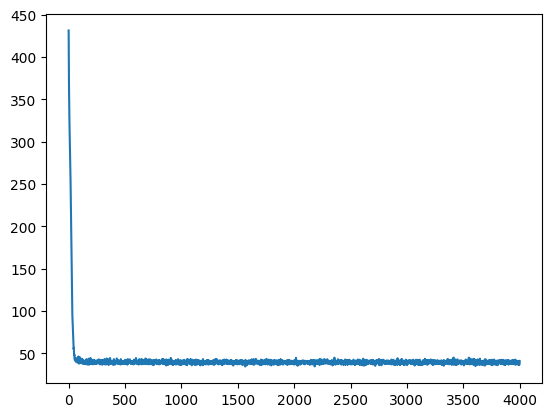

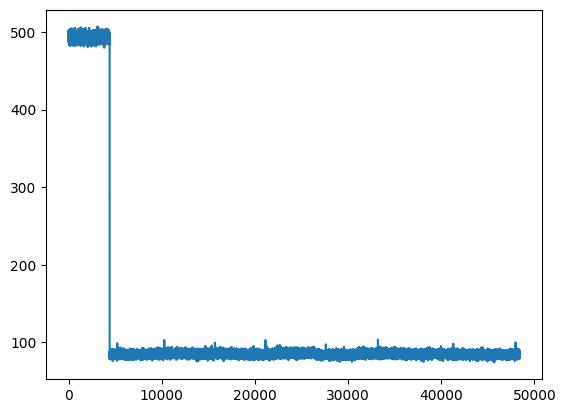

In [ ]:
# plt.plot(test_losses, label='Test Loss')
print(len(train_losses))
print(len(test_losses))
plt.plot(train_losses, label='Train Loss')
plt.show()
plt.plot(test_losses, label='Test Loss')
plt.show()

These curves demonstrate that the model is indeed learning. As expected, the training loss is considerably more stable than the testing loss. This behavior aligns with our understanding: the model performs well on familiar events while showing uncertainty when faced with new or unusual events. However, the loss values plateau quickly, suggesting there is room for further optimization—a topic we plan to explore later. One peculiar aspect of the curves is that the test loss remains relatively high until a certain point, after which it drops dramatically to a much lower value. The reason behind this abrupt change remains unclear.
# Results
Now lets examine our reconstruction errors.

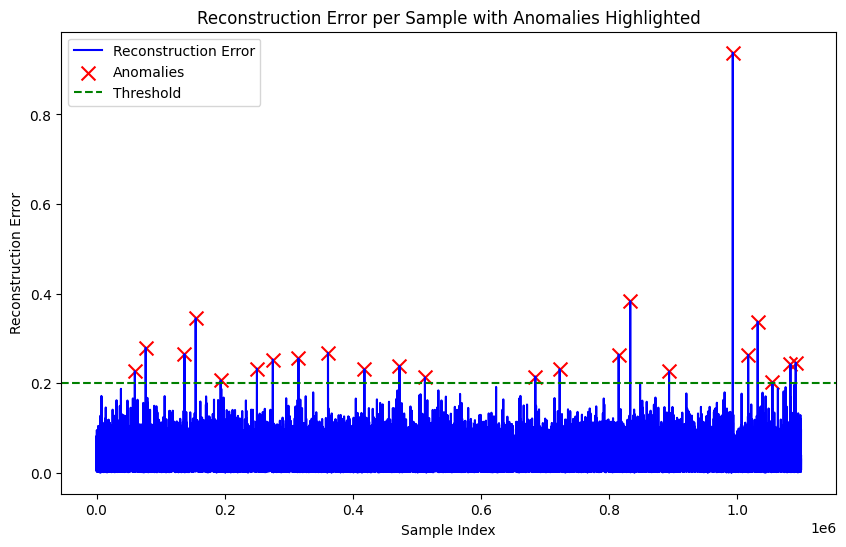

In [ ]:
threshold = 0.2
all_errors = np.array(all_errors)

# Identify indices where error exceeds threshold (anomalies)
anomaly_indices = np.where(all_errors > threshold)[0]
anomaly_errors = all_errors[anomaly_indices]

# Plot the reconstruction errors
plt.figure(figsize=(10, 6))
plt.plot(all_errors, label="Reconstruction Error", color='blue')
# Mark anomalies with red 'x' markers
plt.scatter(anomaly_indices, anomaly_errors, color='red', marker='x', s=100, label="Anomalies")
# Plot a horizontal line showing the threshold
plt.axhline(y=threshold, color='green', linestyle='--', label="Threshold")

plt.xlabel("Sample Index")
plt.ylabel("Reconstruction Error")
plt.title("Reconstruction Error per Sample with Anomalies Highlighted")
plt.legend()
plt.show()

This graph plots every reconstruction error, and any error exceeding a specified threshold is flagged as an anomaly (represented by a red X). The threshold can be adjusted: raising it will flag only the most extreme anomalies, while lowering it will capture a broader set of events, albeit including some that may be less unusual.

# Optimization

First lets optimize the learning rate by iterating through a couple values. We'll start with the learning rate.

In [ ]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]
batchsize = 250
epochs = 10

for lr in learning_rates:
    print(f"Testing with learning rate: {lr}")

    torch.manual_seed(123)
    torch.cuda.manual_seed(123)

    kwargs = {'num_workers': 1, 'pin_memory': True, 'batch_size': batchsize, 'shuffle': True}
    train_loader = torch.utils.data.DataLoader(X_train, **kwargs)
    test_loader = torch.utils.data.DataLoader(X_test, **kwargs)

    model = VAE().to(device)

    loss_function = loss_function_MSE
    optim = torch.optim.Adam(model.parameters(), lr=lr)

    trainmodel()

Testing with learning rate: 0.1
====> Epoch: 1 Average loss: 0.1734
====> Epoch: 2 Average loss: 0.1574
====> Epoch: 3 Average loss: 0.1573
====> Epoch: 4 Average loss: 0.1573
====> Epoch: 5 Average loss: 0.1573
====> Epoch: 6 Average loss: 0.1573
====> Epoch: 7 Average loss: 0.1573
====> Epoch: 8 Average loss: 0.1574
====> Epoch: 9 Average loss: 0.1573
====> Epoch: 10 Average loss: 0.1575
Testing with learning rate: 0.01
====> Epoch: 1 Average loss: 0.2344
====> Epoch: 2 Average loss: 0.1574
====> Epoch: 3 Average loss: 0.1572
====> Epoch: 4 Average loss: 0.1571
====> Epoch: 5 Average loss: 0.1571
====> Epoch: 6 Average loss: 0.1570
====> Epoch: 7 Average loss: 0.1570
====> Epoch: 8 Average loss: 0.1570
====> Epoch: 9 Average loss: 0.1570
====> Epoch: 10 Average loss: 0.1570
Testing with learning rate: 0.001
====> Epoch: 1 Average loss: 0.6998
====> Epoch: 2 Average loss: 0.1717
====> Epoch: 3 Average loss: 0.1618
====> Epoch: 4 Average loss: 0.1592
====> Epoch: 5 Average loss: 0.1580

It seems that while they all performed similarly 0.001 had the best results so we will stick with that and now test for batch sizes.

In [ ]:
batch_sizes = [1000, 500, 250, 64, 32]
lr = 0.001

for bs in batch_sizes:
    print(f"Testing with batch size: {bs}")

    torch.manual_seed(123)
    torch.cuda.manual_seed(123)

    kwargs = {'num_workers': 1, 'pin_memory': True, 'batch_size': bs, 'shuffle': True}
    train_loader = torch.utils.data.DataLoader(X_train, **kwargs)
    test_loader = torch.utils.data.DataLoader(X_test, **kwargs)

    model = VAE().to(device)

    loss_function = loss_function_MSE
    optim = torch.optim.Adam(model.parameters(), lr=lr)

    trainmodel()

Testing with batch size: 1000
====> Epoch: 1 Average loss: 1.3885
====> Epoch: 2 Average loss: 0.8289
====> Epoch: 3 Average loss: 0.3579
====> Epoch: 4 Average loss: 0.2134
====> Epoch: 5 Average loss: 0.1822
====> Epoch: 6 Average loss: 0.1722
====> Epoch: 7 Average loss: 0.1678
====> Epoch: 8 Average loss: 0.1651
====> Epoch: 9 Average loss: 0.1634
====> Epoch: 10 Average loss: 0.1621
Testing with batch size: 500
====> Epoch: 1 Average loss: 1.1087
====> Epoch: 2 Average loss: 0.2852
====> Epoch: 3 Average loss: 0.1772
====> Epoch: 4 Average loss: 0.1663
====> Epoch: 5 Average loss: 0.1628
====> Epoch: 6 Average loss: 0.1609
====> Epoch: 7 Average loss: 0.1596
====> Epoch: 8 Average loss: 0.1588
====> Epoch: 9 Average loss: 0.1583
====> Epoch: 10 Average loss: 0.1579
Testing with batch size: 250
====> Epoch: 1 Average loss: 0.6998
====> Epoch: 2 Average loss: 0.1717
====> Epoch: 3 Average loss: 0.1618
====> Epoch: 4 Average loss: 0.1592
====> Epoch: 5 Average loss: 0.1580
====> Epoc

while anything 250 or lower seemed to yield similar values, 250 was the fastest by far so we will use that as our batch size. Finally lets see if the model will learn any more with a few more epochs.

In [ ]:
bs = 250
lr = 0.001
epoch_sizes = [5, 10, 15, 20]

for epochs in epoch_sizes:
    print(f"Testing with {epochs} epochs")

    torch.manual_seed(123)
    torch.cuda.manual_seed(123)

    kwargs = {'num_workers': 1, 'pin_memory': True, 'batch_size': bs, 'shuffle': True}
    train_loader = torch.utils.data.DataLoader(X_train, **kwargs)
    test_loader = torch.utils.data.DataLoader(X_test, **kwargs)

    model = VAE().to(device)

    loss_function = loss_function_MSE
    optim = torch.optim.Adam(model.parameters(), lr=lr)

    trainmodel()

Testing with 5 epochs
====> Epoch: 1 Average loss: 0.6998
====> Epoch: 2 Average loss: 0.1717
====> Epoch: 3 Average loss: 0.1618
====> Epoch: 4 Average loss: 0.1592
====> Epoch: 5 Average loss: 0.1580
Testing with 10 epochs
====> Epoch: 1 Average loss: 0.6998
====> Epoch: 2 Average loss: 0.1717
====> Epoch: 3 Average loss: 0.1618
====> Epoch: 4 Average loss: 0.1592
====> Epoch: 5 Average loss: 0.1580
====> Epoch: 6 Average loss: 0.1574
====> Epoch: 7 Average loss: 0.1572
====> Epoch: 8 Average loss: 0.1570
====> Epoch: 9 Average loss: 0.1569
====> Epoch: 10 Average loss: 0.1568
Testing with 15 epochs
====> Epoch: 1 Average loss: 0.6998
====> Epoch: 2 Average loss: 0.1717
====> Epoch: 3 Average loss: 0.1618
====> Epoch: 4 Average loss: 0.1592
====> Epoch: 5 Average loss: 0.1580
====> Epoch: 6 Average loss: 0.1574
====> Epoch: 7 Average loss: 0.1572
====> Epoch: 8 Average loss: 0.1570
====> Epoch: 9 Average loss: 0.1569
====> Epoch: 10 Average loss: 0.1568
====> Epoch: 11 Average loss: 

It seems to learn a bit more from 15 rather than 10 epochs so we will now recalculate with our optimized parameters and view the annomaly grpah.

In [ ]:
torch.manual_seed(123)
torch.cuda.manual_seed(123)

epochs = 15
lr = 0.001
bs = 250

kwargs = {'num_workers': 1, 'pin_memory': True, 'batch_size': bs, 'shuffle': True}
train_loader = torch.utils.data.DataLoader(X_train, **kwargs)
test_loader = torch.utils.data.DataLoader(X_test, **kwargs)

model = VAE().to(device)

loss_function = loss_function_MSE
optim = torch.optim.Adam(model.parameters(), lr=lr)

In [ ]:
all_errors, train_losses, test_losses = trainmodel()

====> Epoch: 1 Average loss: 0.6998
====> Epoch: 2 Average loss: 0.1717
====> Epoch: 3 Average loss: 0.1618
====> Epoch: 4 Average loss: 0.1592
====> Epoch: 5 Average loss: 0.1580
====> Epoch: 6 Average loss: 0.1574
====> Epoch: 7 Average loss: 0.1572
====> Epoch: 8 Average loss: 0.1570
====> Epoch: 9 Average loss: 0.1569
====> Epoch: 10 Average loss: 0.1568
====> Epoch: 11 Average loss: 0.1568
====> Epoch: 12 Average loss: 0.1568
====> Epoch: 13 Average loss: 0.1567
====> Epoch: 14 Average loss: 0.1567
====> Epoch: 15 Average loss: 0.1567


([np.float32(0.007945296),
  np.float32(0.038379345),
  np.float32(0.045600116),
  np.float32(0.01402162),
  np.float32(0.039965544),
  np.float32(0.029252047),
  np.float32(0.03498398),
  np.float32(0.022575347),
  np.float32(0.01666383),
  np.float32(0.0038453762),
  np.float32(0.027227256),
  np.float32(0.022257527),
  np.float32(0.026809856),
  np.float32(0.061362393),
  np.float32(0.024726842),
  np.float32(0.04039189),
  np.float32(0.040507678),
  np.float32(0.021222642),
  np.float32(0.032095212),
  np.float32(0.015420647),
  np.float32(0.02920461),
  np.float32(0.032669306),
  np.float32(0.017889557),
  np.float32(0.02077946),
  np.float32(0.024509255),
  np.float32(0.03253631),
  np.float32(0.024641145),
  np.float32(0.025115913),
  np.float32(0.036598716),
  np.float32(0.00901742),
  np.float32(0.013612139),
  np.float32(0.031914286),
  np.float32(0.015386684),
  np.float32(0.00323315),
  np.float32(0.026119044),
  np.float32(0.034440223),
  np.float32(0.023946956),
  np.floa

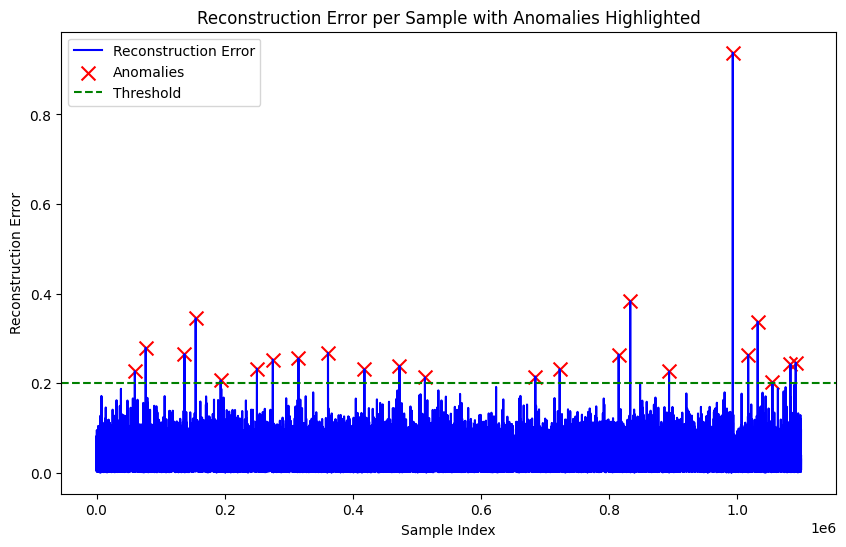

In [ ]:
threshold = 0.2
all_errors = np.array(all_errors)

anomaly_indices = np.where(all_errors > threshold)[0]
anomaly_errors = all_errors[anomaly_indices]

plt.figure(figsize=(10, 6))
plt.plot(all_errors, label="Reconstruction Error", color='blue')
plt.scatter(anomaly_indices, anomaly_errors, color='red', marker='x', s=100, label="Anomalies")
plt.axhline(y=threshold, color='green', linestyle='--', label="Threshold")

plt.xlabel("Sample Index")
plt.ylabel("Reconstruction Error")
plt.title("Reconstruction Error per Sample with Anomalies Highlighted")
plt.legend()
plt.show()

This did see some slight improvement with the average losses shrinking while the annomalus cases slightly increasing.